# Apoio didático - PPGCC
## - Aula 5 - Aprendizado de Máquina: Aprendizado Supervisionado: O método dos $k$ vizinhos mais próximos
Prof. Dr. Rodrigo Colnago Contreras

---
# Exemplos Resolvidos

## Exemplo 1

Dados os seguintes pontos de **X** e suas respectivas classes em **Y** que definem um conjunto de treinamento $D_{\text{treino}}$:

<table style="border-collapse:collapse; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc; padding:6px;">X</th>
      <th style="border:1px solid #ccc; padding:6px;">x₁ = (4,1)</th>
      <th style="border:1px solid #ccc; padding:6px;">x₂ = (1,4)</th>
      <th style="border:1px solid #ccc; padding:6px;">x₃ = (1,1)</th>
      <th style="border:1px solid #ccc; padding:6px;">x₄ = (4,4)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th style="border:1px solid #ccc; padding:6px; font-weight:700;">Y</th>
      <td style="border:1px solid #ccc; padding:6px;"><span style="color:#1565c0; font-weight:600;">C₁ = Azul</span></td>
      <td style="border:1px solid #ccc; padding:6px;"><span style="color:#1565c0; font-weight:600;">C₂ = Azul</span></td>
      <td style="border:1px solid #ccc; padding:6px;"><span style="color:#c62828; font-weight:600;">C₃ = Vermelho</span></td>
      <td style="border:1px solid #ccc; padding:6px;"><span style="color:#c62828; font-weight:600;">C₄ = Vermelho</span></td>
    </tr>
  </tbody>
</table>

**Tarefas**

1. Utilize um **1-NN** para estimar a classe do ponto $\mathbf{x}_{\text{novo}}=(2,3)$.
2. E se fosse um **3-NN**?

**Considere como distância** (Manhattan):
$$
d_{\text{Manhattan}}(\mathbf{x}, \mathbf{y}) \;=\; \sum_{i=1}^{n} \left| x_i - y_i \right|.
$$


### \# Solução:~>

In [1]:
# Solução:~>

import numpy as np
from sklearn.metrics import pairwise_distances
from statistics import mode


def knn_classifier(X_treino, Y_treino, x, k=3, d_nome = "manhattan"):

  dist = pairwise_distances(X_treino, [x], metric=d_nome)

  min_dist_index = np.argsort(dist.ravel())

  classes_dos_NN = Y_treino[min_dist_index[:k]]

  return mode(classes_dos_NN)


In [2]:
x1 = (4,1) # Tuplas
x2 = (1,4)
x3 = (1,1)
x4 = (4,4)

C1 = "Azul"
C2 = "Azul"
C3 = "Vermelho"
C4 = "Vermelho"

X_treino = np.asarray([x1, x2, x3, x4])
Y_treino = np.asarray([C1, C2, C3, C4])

x_novo = (2,3)

In [3]:
y_1nn = knn_classifier(X_treino, Y_treino, x_novo, k=1)
print("Classe predita usando 1-NN: ", y_1nn)

y_3nn = knn_classifier(X_treino, Y_treino, x_novo, k=3)
print("Classe predita usando 3-NN: ", y_3nn)

Classe predita usando 1-NN:  Azul
Classe predita usando 3-NN:  Vermelho


---

## Biblioteca sci-kit learn:

In [4]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Criar modelo
knn = KNeighborsClassifier(n_neighbors=1, metric='manhattan')

# 2. Treinar
knn.fit(X_treino, Y_treino) # construir a \hat{f} (preditor)

# 3. Classificar novos exemplos
X_teste = [x_novo]
y_1nn = knn.predict(X_teste) # Fazer a estimação/predição

print("Classe predita usando 1-NN: ", y_1nn[0])


Classe predita usando 1-NN:  Azul


In [5]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Criar modelo
knn = KNeighborsClassifier(n_neighbors=3, metric='manhattan')

# 2. Treinar
knn.fit(X_treino, Y_treino)

# 3. Classificar novos exemplos
X_teste = [x_novo]
y_3nn = knn.predict(X_teste)

print("Classe predita usando 3-NN: ", y_3nn[0])


Classe predita usando 3-NN:  Vermelho


## Exemplo 2: Uso de $k$-NN em uma base de dados do mundo real.

## Visão geral do conjunto
O `load_breast_cancer` (Wisconsin Diagnostic Breast Cancer) contém **569 amostras** com **30 atributos numéricos** extraídos de imagens digitalizadas de agulha fina (FNA) de massas mamárias.

- **Classes (y):** `malignant` (maligno) e `benign` (benigno).
- **Atributos (X):** 30 variáveis reais, derivadas de **10 medidas básicas**, cada uma computada em três variações: **mean**, **se** (erro padrão) e **worst** (maior valor em um vizinho de 10 pixeis).

As **10 medidas básicas** são:
1. `radius` – média dos raios dos perímetros (distância do centro aos pontos na borda)  
2. `texture` – desvio padrão dos níveis de cinza  
3. `perimeter` – perímetro do tumor  
4. `area` – área do tumor  
5. `smoothness` – variação local de raios (suavidade)  
6. `compactness` – $$\frac{perimeter^2}{area} - 1.0$$ (medida de compacidade)  
7. `concavity` – severidade das côncavas (reentrâncias) da borda  
8. `concave\ points` – número de porções côncavas da borda  
9. `symmetry` – simetria da forma  
10. `fractal\ dimension` – aproximação da dimensão fractal da borda

Como cada medida aparece em **mean**, **se** e **worst**, temos 30 colunas, por exemplo:
- `radius_mean`, `texture_mean`, …  
- `radius_se`, `texture_se`, …  
- `radius_worst`, `texture_worst`, …

## Objetivo do exercício
1) Carregar o dataset.  
2) Definir os conjuntos de treino e de teste de forma que os primeiros **75%** exemplos formam os dados de treinamento e os demais **25%** definem os dados de teste.
3) Ajustar um $k$-NN com distância euclidiana e reportar a acurácia em teste para $k=1$ e para $k=3$.

> **Observação didática:** uma divisão **linear** (primeiros 75% para treino e últimos 25% para teste) pode introduzir **viés temporal/ordenação** se os dados estiverem ordenados por algum critério. Use aqui por fins pedagógicos; em produção, prefira **embaralhar** (shuffle) e **estratificar**.

## Fórmula do corte 75%/25%
$$
n_{\text{treino}} = \left\lfloor 0.75 \cdot N \right\rfloor,\quad
n_{\text{teste}} = N - n_{\text{treino}}
$$

## Passo a passo (código de referência)
> Execute os blocos Python abaixo em células separadas do Colab.

### 1) Carregar e inspecionar
```python
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0=malignant, 1=benign

N = len(X)
print("Amostras:", N)
print("Classes:", dict(zip(data.target_names, np.unique(y, return_counts=True)[1])))
X.head()


### \# Solução:~>

In [6]:
# from sklearn.datasets import load_breast_cancer
# import pandas as pd
# import numpy as np

# #data = load_breast_cancer()
# #X = pd.DataFrame(data.data, columns=data.feature_names)
# #Y = pd.Series(data.target, name="target")  # 0=malignant, 1=benign

# X = pd.read_csv("WDBC_X.csv", index_col=0)
# Y = pd.read_csv("WDBC_Y.csv")
# Y = Y['target']


# N = len(X)
# print("Amostras:", N)
# print("Classes:", dict(zip(['maligno', 'benigno'], np.unique(Y, return_counts=True)[1])))
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 0=malignant, 1=benign

N = len(X)
print("Amostras:", N)
print("Classes:", dict(zip(data.target_names, np.unique(y, return_counts=True)[1])))

X

Amostras: 569
Classes: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [7]:
y.value_counts()

,count
target,
1,357
0,212


### Definição de Conjuntos de Treino e de Teste

In [10]:
N_treino = int(0.75 * N)

X_treino = X.iloc[:N_treino]
Y_treino = y.iloc[:N_treino]

X_teste = X.iloc[N_treino:]
Y_teste = y.iloc[N_treino:]

### Ajuste e avaliação dos modelos

In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1, metric="euclidean")
knn.fit(X_treino, Y_treino)

classes_preditas = knn.predict(X_teste)
print("acc =", np.sum(Y_teste == classes_preditas) / len(Y_teste))

acc = 0.9230769230769231


In [12]:
# pipeline com padronização (importante pro k-NN)
knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")
knn.fit(X_treino, Y_treino)

classes_preditas = knn.predict(X_teste)
print("acc =", np.sum(Y_teste == classes_preditas) / len(Y_teste))

acc = 0.9300699300699301


## **Exemplo 3**: Refaça o Exemplo 2 utilizando estratégias de escala sobre os dados de treinamento.

Sugestão: Utilize quatro estratégias: a min-max, a z-score, a robusta e a do máximo. Confeccione uma função para tal e utilize as respectivas classes (```StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler```) do ```sklearn```. Segue o exemplo de uso da padronização:

```python
from sklearn.preprocessing import StandardScaler

escala = StandardScaler()

escala.fit(X_treino)

X_treino_reescalado = escala.transform(X_treino)
X_teste_reescalado = escala.transform(X_teste)
```

### \# Solução:~>

### Uso de funções próprias de escala

In [13]:
# Confecção de funções de escala:

# Funções de escalas

def maxabs_scaling(X_treino, X_teste = []):
    if len(X_teste) > 0:
      return X_treino / np.abs(X_treino).max(axis=0), X_teste / np.abs(X_treino).max(axis=0)
    else:
      return X_treino / np.abs(X_treino).max(axis=0)

def min_max_scaling(X_treino, X_teste = []):
    if len(X_teste) > 0:
      return 2*(X_treino - X_treino.min(axis=0)) / (X_treino.max(axis=0) - X_treino.min(axis=0)) -1,   2*(X_teste - X_treino.min(axis=0)) / (X_treino.max(axis=0) - X_treino.min(axis=0)) -1
    else:
      return 2*(X_treino - X_treino.min(axis=0)) / (X_treino.max(axis=0) - X_treino.min(axis=0))-1

def z_score_standardization(X_treino, X_teste = []):
    if len(X_teste) > 0:
      return (X_treino - X_treino.mean(axis=0)) / X_treino.std(axis=0), (X_teste - X_treino.mean(axis=0)) / X_treino.std(axis=0)
    else:
      return (X_treino - X_treino.mean(axis=0)) / X_treino.std(axis=0)

def robust_scaling(X_treino, X_teste = []):
    q1 = np.percentile(X_treino, 25, axis=0)
    q3 = np.percentile(X_treino, 75, axis=0)
    iqr = q3 - q1
    median = np.median(X_treino, axis=0)

    if len(X_teste) > 0:
      return (X_treino - median) / iqr, (X_teste - median) / iqr
    else:
      return (X_treino - median) / iqr


In [14]:
# Aplicando os métodos
X_treino_minmax, X_teste_minmax = min_max_scaling(X_treino, X_teste)
X_treino_zscore, X_teste_zscore = z_score_standardization(X_treino, X_teste)
X_treino_robust, X_teste_robust = robust_scaling(X_treino, X_teste)
X_treino_maxabs, X_teste_maxabs = maxabs_scaling(X_treino, X_teste)

# Definindo o objeto knn
knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")

# Usando o classificador knn com escala minmax
knn.fit(X_treino_minmax, Y_treino)
classes_preditas = knn.predict(X_teste_minmax)
print("acc (minmax) =", np.sum(Y_teste == classes_preditas) / len(Y_teste))

# Usando o classificador knn com escala zscore
knn.fit(X_treino_zscore, Y_treino)
classes_preditas = knn.predict(X_teste_zscore)
print("acc (zscore) =", np.sum(Y_teste == classes_preditas) / len(Y_teste))

# Usando o classificador knn com escala robust
knn.fit(X_treino_robust, Y_treino)
classes_preditas = knn.predict(X_teste_robust)
print("acc (robust) =", np.sum(Y_teste == classes_preditas) / len(Y_teste))

# Usando o classificador knn com escala maxabs
knn.fit(X_treino_maxabs, Y_treino)
classes_preditas = knn.predict(X_teste_maxabs)
print("acc (maxabs) =", np.sum(Y_teste == classes_preditas) / len(Y_teste))



acc (minmax) = 0.965034965034965
acc (zscore) = 0.951048951048951
acc (robust) = 0.958041958041958
acc (maxabs) = 0.9790209790209791


### Uso de funções do sklearn preprocessing

In [15]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, MaxAbsScaler

# pipeline com padronização (importante pro k-NN)
knn = KNeighborsClassifier(n_neighbors=3, metric="euclidean")

# Escala min-max
escala = MinMaxScaler()
escala.fit(X_treino)
X_treino_minmax = escala.transform(X_treino)
X_teste_minmax = escala.transform(X_teste)

knn.fit(X_treino_minmax, Y_treino)
classes_preditas = knn.predict(X_teste_minmax)
print("acc (minmax) =", np.sum(Y_teste == classes_preditas) / len(Y_teste))

# Escala Z-Score (Padronização)
escala = StandardScaler()
escala.fit(X_treino)
X_treino_zscore = escala.transform(X_treino)
X_teste_zscore = escala.transform(X_teste)

knn.fit(X_treino_zscore, Y_treino)
classes_preditas = knn.predict(X_teste_zscore)
print("acc (zscore) =", np.sum(Y_teste == classes_preditas) / len(Y_teste))

# Escala Robusta
escala = RobustScaler()
escala.fit(X_treino)
X_treino_robust = escala.transform(X_treino)
X_teste_robust = escala.transform(X_teste)

knn.fit(X_treino_robust, Y_treino)
classes_preditas = knn.predict(X_teste_robust)
print("acc (robust) =", np.sum(Y_teste == classes_preditas) / len(Y_teste))


# Escala Máximo
escala = MaxAbsScaler()
escala.fit(X_treino)
X_treino_maxabs = escala.transform(X_treino)
X_teste_maxabs = escala.transform(X_teste)

knn.fit(X_treino_maxabs, Y_treino)
classes_preditas = knn.predict(X_teste_maxabs)
print("acc (maxabs) =", np.sum(Y_teste == classes_preditas) / len(Y_teste))

acc (minmax) = 0.965034965034965
acc (zscore) = 0.951048951048951
acc (robust) = 0.958041958041958
acc (maxabs) = 0.9790209790209791


## **Exemplo 4** Considere a mesma divisão de treino e teste usada nos exemplos anteriores da base WDBC. Otimize os hiperparâmetros do classificador **$k$-NN** avaliando as seguintes combinações:

- Número de vizinhos:
$$
k \in \{1, 3, 5, 7, ..., 29\},
$$

- Métrica de distância:
$$
d \in \{d_\text{euclidiana},\ d_\text{Manhattan},\ d_\text{Chebyshev}\}.
$$

Obs.: Verifique também qual é a melhor escala para os dados deste problema.

> **Observações**  
> - Mantenha a **mesma divisão** de treino/teste para garantir comparabilidade.  
> - Padronize as features no **conjunto de treino** e aplique a mesma transformação no **conjunto de teste** (evitar vazamento).  
> - Registre a **melhor combinação** encontrada e a métrica obtida (ex.: acurácia ou erro).


### \# Solução:~>

In [16]:
import pandas as pd


# Espaço de busca para os Hiperparâmetros
ks = list(range(1,30,2))
metrics = ["euclidean", "manhattan", "chebyshev"]

# Escalas a avaliar
scalers = [
    ("minmax",  MinMaxScaler()),
    ("zscore",  StandardScaler()),
    ("robust",  RobustScaler()),
    ("maxabs",  MaxAbsScaler())
]

resultados = []

for sc_name, scaler in scalers:
    # Ajusta no treino e aplica no treino e teste (sem vazamento)
    X_treino_reescalado = scaler.fit_transform(X_treino)
    X_teste_reescalado = scaler.transform(X_teste)

    for k in ks: # Otimização de Hiperparâmetro
        for met in metrics:
            knn = KNeighborsClassifier(n_neighbors=k, metric=met)
            knn.fit(X_treino_reescalado, Y_treino)
            y_pred = knn.predict(X_teste_reescalado)
            ACC = np.sum(y_pred == Y_teste) / len(Y_teste)

            resultados.append({
                "Escala": sc_name,
                "k": k,
                "Distância": met,
                "Acc": ACC
            })

# Tabela de resultados
df = pd.DataFrame(resultados).sort_values(["Acc", "Escala", "k"], ascending=[False, True, True]).reset_index(drop=True)
print(df.to_string(index=False))

# Melhor por escala
print("\nMelhor combinação por escala:")
print(df.loc[df.groupby("Escala")["Acc"].idxmax()].sort_values("Acc", ascending = False).to_string(index=False))

# Melhor global
best = df.iloc[0]
print(f"\nMelhor global → escala={best['Escala']}, k={best['k']}, d={best['Distância']}, Acc={best['Acc']:.4f}")


Escala  k Distância      Acc
minmax  5 manhattan 1.000000
minmax 11 euclidean 1.000000
maxabs  3 manhattan 0.993007
maxabs  9 euclidean 0.993007
maxabs  9 manhattan 0.993007
maxabs 11 euclidean 0.993007
minmax  7 manhattan 0.993007
minmax 11 manhattan 0.993007
robust  7 manhattan 0.993007
maxabs  5 manhattan 0.986014
maxabs 13 euclidean 0.986014
maxabs 13 manhattan 0.986014
maxabs 15 euclidean 0.986014
maxabs 15 manhattan 0.986014
maxabs 17 manhattan 0.986014
maxabs 21 euclidean 0.986014
maxabs 23 euclidean 0.986014
maxabs 25 euclidean 0.986014
maxabs 27 euclidean 0.986014
minmax  7 euclidean 0.986014
minmax  9 euclidean 0.986014
minmax  9 manhattan 0.986014
minmax 13 euclidean 0.986014
minmax 21 euclidean 0.986014
minmax 23 euclidean 0.986014
robust  7 euclidean 0.986014
robust 13 euclidean 0.986014
robust 15 euclidean 0.986014
robust 17 euclidean 0.986014
robust 21 euclidean 0.986014
robust 23 euclidean 0.986014
robust 29 euclidean 0.986014
zscore  5 manhattan 0.986014
zscore  7 manh

In [17]:
df

,Escala,k,Distância,Acc
0,minmax,5,manhattan,1.000000
1,minmax,11,euclidean,1.000000
2,maxabs,3,manhattan,0.993007
3,maxabs,9,euclidean,0.993007
4,maxabs,9,manhattan,0.993007
...,...,...,...,...
175,robust,5,chebyshev,0.923077
176,minmax,1,chebyshev,0.902098
177,robust,1,chebyshev,0.881119
178,robust,3,chebyshev,0.881119


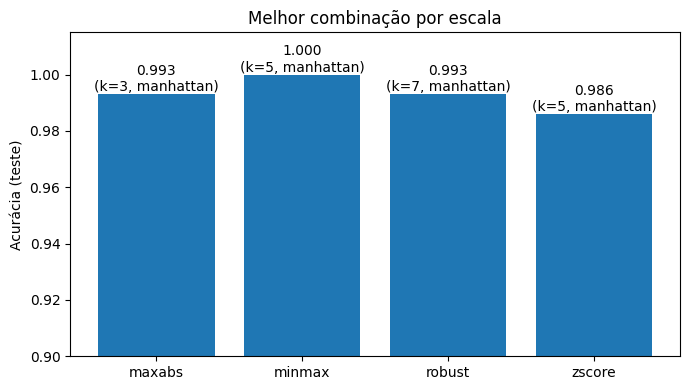

In [18]:
import matplotlib.pyplot as plt

best_per_scale = df.loc[df.groupby("Escala")["Acc"].idxmax()].copy()
best_per_scale = best_per_scale.sort_values("Escala")

plt.figure(figsize=(7,4))
plt.bar(best_per_scale["Escala"], best_per_scale["Acc"])
for i, v in enumerate(best_per_scale["Acc"]):
    plt.text(i, v, f"{v:.3f}\n(k={int(best_per_scale.iloc[i]['k'])}, {best_per_scale.iloc[i]['Distância']})",
             ha='center', va='bottom')
plt.ylabel("Acurácia (teste)")
plt.title("Melhor combinação por escala")
plt.xticks(rotation=0)
plt.ylim(0.9,1.015)
plt.tight_layout()
plt.show()

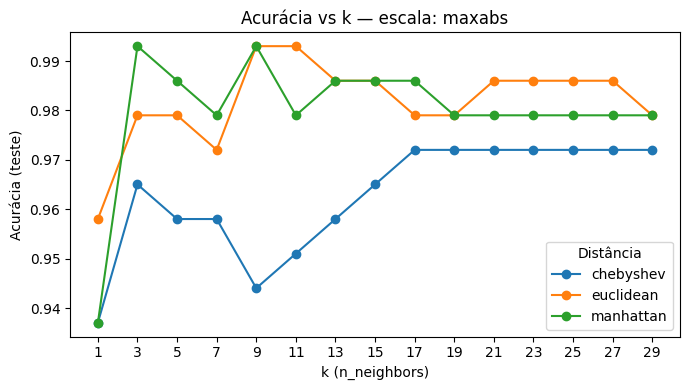

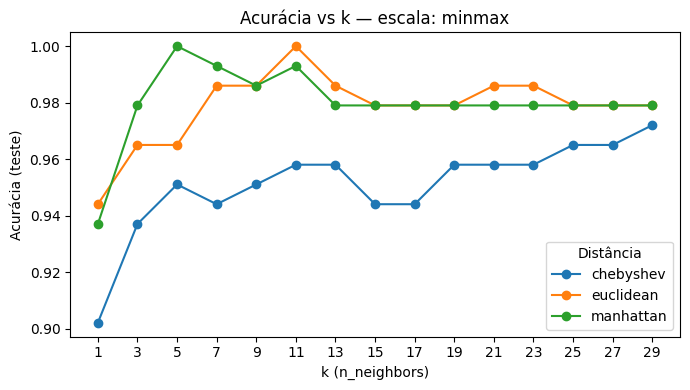

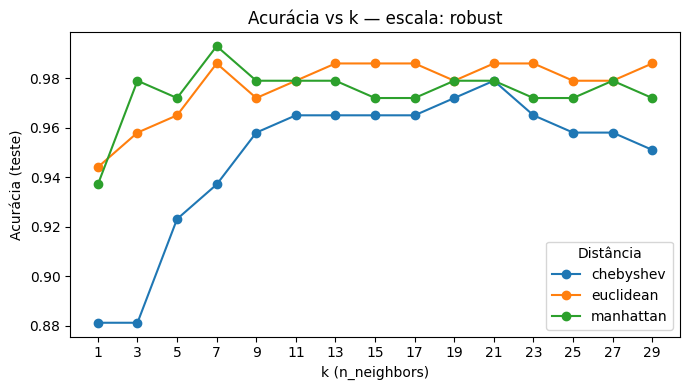

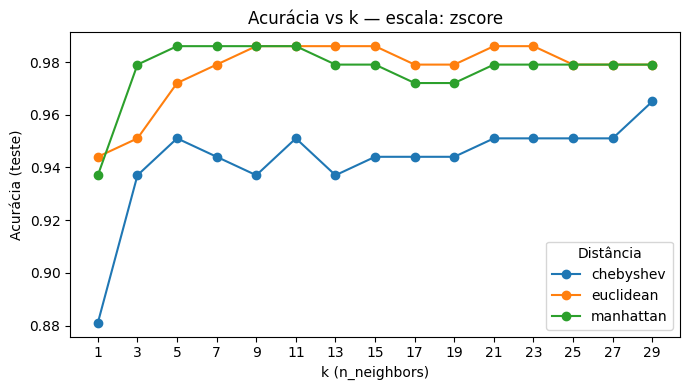

In [19]:
for escala, g in df.groupby("Escala"):
    plt.figure(figsize=(7,4))
    for dist, gg in g.groupby("Distância"):
        gg_sorted = gg.sort_values("k")
        plt.plot(gg_sorted["k"], gg_sorted["Acc"], marker='o', label=dist)
    plt.xlabel("k (n_neighbors)")
    plt.ylabel("Acurácia (teste)")
    plt.title(f"Acurácia vs k — escala: {escala}")
    plt.legend(title="Distância")
    plt.xticks(sorted(g["k"].unique()))
    plt.tight_layout()
    plt.show()


## **Exemplo 5**

Dados os seguintes pontos de **X** e suas respectivas classes em **Y** que definem um conjunto de treinamento $D_{\text{treino}}$:

<table style="border-collapse:collapse; text-align:center;">
  <thead>
    <tr>
      <th style="border:1px solid #ccc; padding:6px;">X</th>
      <th style="border:1px solid #ccc; padding:6px;">x₁ = (4,1)</th>
      <th style="border:1px solid #ccc; padding:6px;">x₂ = (1,4)</th>
      <th style="border:1px solid #ccc; padding:6px;">x₃ = (1,1)</th>
      <th style="border:1px solid #ccc; padding:6px;">x₄ = (4,4)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th style="border:1px solid #ccc; padding:6px; font-weight:700;">Y</th>
      <th style="border:1px solid #ccc; padding:6px;">y₁ = 3.14</td>
      <th style="border:1px solid #ccc; padding:6px;">y₂ = 2.71</td>
      <th style="border:1px solid #ccc; padding:6px;">y₃ = 1.61</td>
      <th style="border:1px solid #ccc; padding:6px;">y₄ = 0.00</td>
    </tr>
  </tbody>
</table>

**Tarefas**

1. Utilize um **1-NN** para estimar a classe do ponto $\mathbf{x}_{\text{novo}}=(2,3)$.
2. E se fosse um **3-NN**?

**Considere como distância** (Manhattan):
$$
d_{\text{Manhattan}}(\mathbf{x}, \mathbf{y}) \;=\; \sum_{i=1}^{n} \left| x_i - y_i \right|.
$$

### \# Solução:~>

In [20]:
import numpy as np
from sklearn.metrics import pairwise_distances
from statistics import mean, median


def knn_regressao(X_treino, Y_treino, x, k=3, d_nome = "manhattan"):

  dist = pairwise_distances(X_treino, [x], metric=d_nome)

  min_dist_index = np.argsort(dist.ravel())

  valores_dos_NN = Y_treino[min_dist_index[:k]]

  return mean(valores_dos_NN)

In [21]:
x1 = (4,1)
x2 = (1,4)
x3 = (1,1)
x4 = (4,4)

y1 = 3.14
y2 = 2.71
y3 = 1.61
y4 = 0.00

X_treino = np.asarray([x1, x2, x3, x4])
Y_treino = np.asarray([y1, y2, y3, y4])

x_novo = (2,3)

In [22]:
y_1nn = knn_regressao(X_treino, Y_treino, x_novo, k=1)
print("Classe predita usando 1-NN: ", y_1nn)

y_3nn = knn_regressao(X_treino, Y_treino, x_novo, k=3)
print("Classe predita usando 3-NN: ", y_3nn)

Classe predita usando 1-NN:  2.71
Classe predita usando 3-NN:  1.44


## **Exemplo 6**: Regressão KNN sobre $f(x) = \sin(x)$

Gere **20 pontos igualmente espaçados** em $[0, \pi]$ para formar os pontos de treinamento em $X$ e $Y$ usando a função seno.  
Isto é:  

$$
x_i = i \cdot \frac{\pi}{19}, \quad y_i = \sin(x_i), \quad i = 0, 1, \dots, 19
$$

Na sequência, defina um **KNN Regressor** com $k = 1$ usando esses pares $(x_i, y_i)$. Experimente outros valores de $k$.

Gere **1000 pontos de teste** igualmente espaçados em $[0, \pi]$ e estime:

$$
\hat{y}_j = \hat{f}(x_j)
$$

nesse mesmo intervalo.

Calcule os erros de aproximação **MSE** e **MAE**  
(*dica:* usar `sklearn.metrics.mean_squared_error` e `mean_absolute_error`).

Por fim, **desenhe**:
- a função real $\sin(x)$;  
- os pontos de treino $(x_i, y_i)$;  
- e a curva estimada pelo KNN.


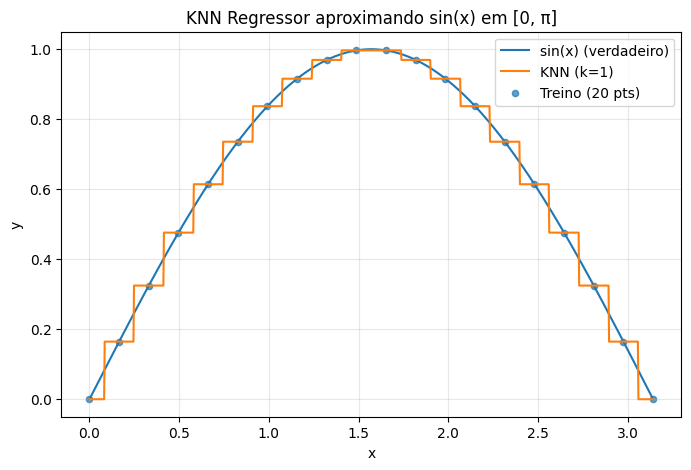

MSE = 0.001138
MAE = 0.026303


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1) Dados de treino (20 pontos igualmente espaçados em [0, pi])
n_train = 20
x_train = np.linspace(0, np.pi, n_train)
y_train = np.sin(x_train)

# 2) Modelo KNN Regressor
k = 1  # experimente 3, 5, 11, 19
knn = KNeighborsRegressor(n_neighbors=k, metric='euclidean')
knn.fit(x_train.reshape(-1, 1), y_train)

# 3) Pontos de teste (1000 pontos em [0, pi])
n_test = 1000
x_test = np.linspace(0, np.pi, n_test)
y_true = np.sin(x_test)

# 4) Predição e plot
y_pred = knn.predict(x_test.reshape(-1, 1))

plt.figure(figsize=(8, 5))
plt.plot(x_test, y_true, label='sin(x) (verdadeiro)')
plt.plot(x_test, y_pred, label=f'KNN (k={k})')
plt.scatter(x_train, y_train, s=20, alpha=0.7, label=f'Treino ({len(x_train)} pts)')
plt.xlabel('x'); plt.ylabel('y')
plt.title('KNN Regressor aproximando sin(x) em [0, π]')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 5) Métricas
mse = mean_squared_error(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)
print(f'MSE = {mse:.6f}')
print(f'MAE = {mae:.6f}')


## **Exemplo 7**: Utilize uma estratégia de janelamento com tamanho de janela $w=3$ para definir um modelo $3$-NN que estime o valor de fechamento da criptomoeda Tether (USDT), cujos dados são fornecidos abaixo. Considere como conjunto de treinamento a série temporal de 01/01/2020 a 30/05/2025, e como conjunto de teste os dados de 01/06/2025 a 28/06/2025. Ao final, apresente os valores de MAE e MSE obtidos pelo modelo no período de teste.


### \# Solução:~>

Apresentação dos dados da criptomoeda Tether (USDT)

In [24]:
import numpy as np
from sklearn.metrics import pairwise_distances
from statistics import mean, median


def knn_regressao(X_treino, Y_treino, x, k=3, d_nome = "manhattan"):

  dist = pairwise_distances(X_treino, [x], metric=d_nome)

  min_dist_index = np.argsort(dist.ravel())

  valores_dos_NN = Y_treino[min_dist_index[:k]]

  return median(valores_dos_NN)

/tmp/ipykernel_5814/2563648457.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth_treino = yf.download("USDT-USD", start="2020-01-01", end="2025-05-30", progress=False)
/tmp/ipykernel_5814/2563648457.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth_teste = yf.download("USDT-USD", start="2025-06-01", end="2025-06-28", progress=False)


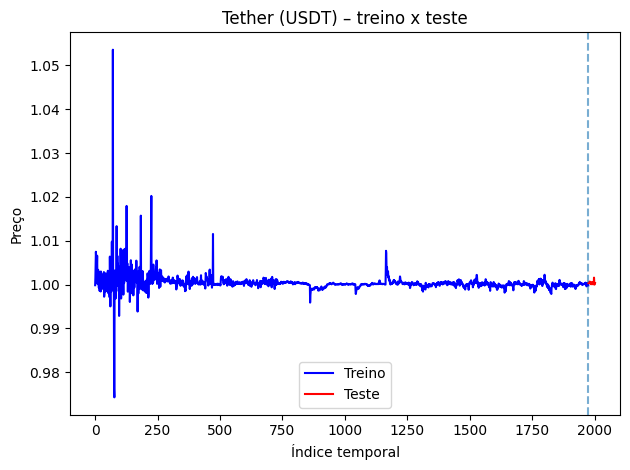

In [26]:
# Solução:~>

import yfinance as yf
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

eth_treino = yf.download("USDT-USD", start="2020-01-01", end="2025-05-30", progress=False)
eth_treino.to_csv('eth_treino.csv')
eth_treino = pd.read_csv('eth_treino.csv', header=[0,1], index_col=0, parse_dates=[0])
prices_eth_treino = eth_treino['Close'].values

eth_teste = yf.download("USDT-USD", start="2025-06-01", end="2025-06-28", progress=False)
eth_teste.to_csv('eth_teste.csv')
eth_teste = pd.read_csv('eth_teste.csv', header=[0,1], index_col=0, parse_dates=[0])
prices_eth_teste = eth_teste['Close'].values

plt.plot(np.arange(len(prices_eth_treino)),prices_eth_treino,'b', label='Treino')
plt.plot([l+len(prices_eth_treino) for l in np.arange(len(prices_eth_teste))],prices_eth_teste,'r', label='Teste')

# linha vertical marcando a divisão
plt.axvline(len(prices_eth_treino)-1, linestyle='--', alpha=0.6)

plt.xlabel('Índice temporal')
plt.ylabel('Preço')
plt.title('Tether (USDT) – treino x teste')
plt.legend()              # cria a legenda com “Treino” (azul) e “Teste” (vermelho)
plt.tight_layout()

Estratégia de janelamento de tamanho $w$ e definição de conjuntos de treino e de teste

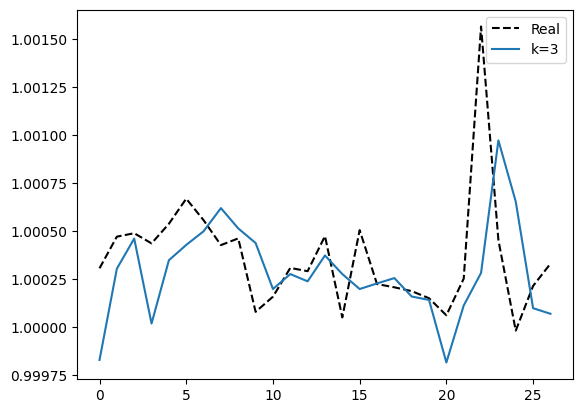

In [27]:
def make_windows(series, w):
    X, y = [], []
    for i in range(w, len(series)):
        X.append(series[i-w:i].ravel())
        y.append(series[i].ravel())
    return np.array(X), np.array(y)



# Série contínua: treino + teste
eth_full = np.concatenate([prices_eth_treino, prices_eth_teste])

# Todas as janelas (com contexto atravessando a fronteira)
X_all, y_all = make_windows(eth_full, 3)

# Índice onde começa o teste na série original
test_start = len(prices_eth_treino)

# Na matriz y_all, o elemento que corresponde ao y[test_start]
# está na posição (test_start - w)
w = 3
borda = test_start - w
if borda < 0:
    raise ValueError("Treino menor que a janela w.")

X_treino = X_all[:borda]
y_treino = y_all[:borda]
X_teste  = X_all[borda:]
y_teste  = y_all[borda:]


X_treino = np.array(X_treino)
y_treino = np.array(y_treino).ravel()
X_teste = np.array(X_teste)
y_teste = np.array(y_teste).ravel()


plt.plot(np.arange(len(y_teste)),y_teste, '--k', label="Real")
for k in [3]:
  y_pred = [knn_regressao(X_treino, y_treino, x, k=k) for x in X_teste]
  plt.plot(np.arange(len(y_pred)),y_pred, label=f'{k=}' )
plt.legend()

In [28]:
# Métricas
mse = mean_squared_error(y_teste, y_pred)
mae = mean_absolute_error(y_teste, y_pred)
print(f'MSE = {mse:.6f}')
print(f'MAE = {mae:.6f}')

MSE = 0.000000
MAE = 0.000232


## **Exemplo 8**: Refaça o exemplo anterior de maneira que a melhor combinação de hiperparâmetros, escala e tamanho de janelamento de série temporal sejam definidos de forma a minimizar o MAE.

Considere:

- $k \in \{1,3,5,...,29\}$
- Métrica de distância: $d \in \{d_\text{euclidiana},\ d_\text{Manhattan},\ d_\text{Chebyshev}\}.$
- $w \in \{ 3,5,7,9,11 \} .$

### \# Solução:~>

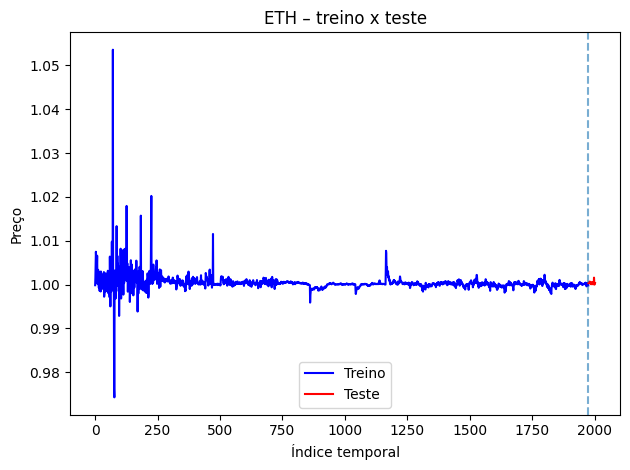

In [29]:
# Solução:~>

import yfinance as yf
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler

eth_treino = pd.read_csv('eth_treino.csv', header=[0,1], index_col=0, parse_dates=[0])
prices_eth_treino = eth_treino['Close'].values

eth_teste = pd.read_csv('eth_teste.csv', header=[0,1], index_col=0, parse_dates=[0])
prices_eth_teste = eth_teste['Close'].values


# Série contínua: treino + teste
eth_full = np.concatenate([prices_eth_treino, prices_eth_teste])

plt.plot(np.arange(len(prices_eth_treino)),prices_eth_treino,'b', label='Treino')
plt.plot([l+len(prices_eth_treino) for l in np.arange(len(prices_eth_teste))],prices_eth_teste,'r', label='Teste')

# linha vertical marcando a divisão
plt.axvline(len(prices_eth_treino)-1, linestyle='--', alpha=0.6)

plt.xlabel('Índice temporal')
plt.ylabel('Preço')
plt.title('ETH – treino x teste')
plt.legend()              # cria a legenda com “Treino” (azul) e “Teste” (vermelho)
plt.tight_layout()



In [30]:
def make_windows(series, w):
    X, y = [], []
    for i in range(w, len(series)):
        X.append(series[i-w:i].ravel())
        y.append(series[i].ravel())
    return np.array(X), np.array(y)

def HP_eval(w, k, scaler):

    # Todas as janelas (com contexto atravessando a fronteira)
    X_all, y_all = make_windows(eth_full, w)

    # Índice onde começa o teste na série original
    test_start = len(prices_eth_treino)

    # Na matriz y_all, o elemento que corresponde ao y[test_start]
    # está na posição (test_start - w)
    borda = test_start - w
    if borda < 0:
        raise ValueError("Treino menor que a janela w.")

    X_treino = X_all[:borda]
    y_treino = y_all[:borda]
    X_teste  = X_all[borda:]
    y_teste  = y_all[borda:]


    X_treino = np.array(X_treino)
    y_treino = np.array(y_treino).ravel()
    X_teste = np.array(X_teste)
    y_teste = np.array(y_teste).ravel()


    # Ajusta no treino e aplica no treino e teste (sem vazamento)
    X_treino_reescalado = scaler.fit_transform(X_treino)
    X_teste_reescalado = scaler.transform(X_teste)




    y_pred = [knn_regressao(X_treino, y_treino, x, k=k) for x in X_teste]

    return mean_absolute_error(y_teste, y_pred)

In [31]:



# Espaço de busca para os Hiperparâmetros
ks = list(range(1,30,2))
metrics = ["euclidean", "manhattan", "chebyshev"]

# Escalas a avaliar
scalers = [
    ("minmax",  MinMaxScaler()),
    ("zscore",  StandardScaler()),
    ("robust",  RobustScaler()),
    ("maxabs",  MaxAbsScaler()),
]

resultados = []

for sc_name, scaler in scalers:

    for k in ks: # Otimização de Hiperparâmetro
        for met in metrics:
            for w in [3,5,7,9,11]:
                print(f"sc = {sc_name}, k = {k}, met = {met}, w = {w}",end='')
                MAE = HP_eval(w, k, scaler)
                print(f" MAE = {MAE:.6}")

                resultados.append({
                    "Escala":sc_name,
                    "w": w,
                    "k": k,
                    "Distância": met,
                    "MAE": MAE
                })

sc = minmax, k = 1, met = euclidean, w = 3 MAE = 0.000326492
sc = minmax, k = 1, met = euclidean, w = 5 MAE = 0.00029635
sc = minmax, k = 1, met = euclidean, w = 7 MAE = 0.000225462
sc = minmax, k = 1, met = euclidean, w = 9 MAE = 0.000220202
sc = minmax, k = 1, met = euclidean, w = 11 MAE = 0.000239032
sc = minmax, k = 1, met = manhattan, w = 3 MAE = 0.000326492
sc = minmax, k = 1, met = manhattan, w = 5 MAE = 0.00029635
sc = minmax, k = 1, met = manhattan, w = 7 MAE = 0.000225462
sc = minmax, k = 1, met = manhattan, w = 9 MAE = 0.000220202
sc = minmax, k = 1, met = manhattan, w = 11 MAE = 0.000239032
sc = minmax, k = 1, met = chebyshev, w = 3 MAE = 0.000326492
sc = minmax, k = 1, met = chebyshev, w = 5 MAE = 0.00029635
sc = minmax, k = 1, met = chebyshev, w = 7 MAE = 0.000225462
sc = minmax, k = 1, met = chebyshev, w = 9 MAE = 0.000220202
sc = minmax, k = 1, met = chebyshev, w = 11 MAE = 0.000239032
sc = minmax, k = 3, met = euclidean, w = 3 MAE = 0.00023231
sc = minmax, k = 3, met =

In [32]:
# Tabela de resultados
df = pd.DataFrame(resultados).sort_values(["MAE", "Escala", "k"], ascending=[True, True, True]).reset_index(drop=True)
print(df.to_string(index=False))

# Melhor por escala
print("\nMelhor combinação por escala:")
print(df.loc[df.groupby("Escala")["MAE"].idxmin()].sort_values("Escala").to_string(index=False))

# Melhor global
best = df.iloc[0]
print(f"\nMelhor global → escala={best['Escala']}, k={best['k']}, d={best['Distância']}, MAE={best['MAE']:.6f}")


Escala  w  k Distância      MAE
maxabs 11  3 euclidean 0.000189
maxabs 11  3 manhattan 0.000189
maxabs 11  3 chebyshev 0.000189
minmax 11  3 euclidean 0.000189
minmax 11  3 manhattan 0.000189
minmax 11  3 chebyshev 0.000189
robust 11  3 euclidean 0.000189
robust 11  3 manhattan 0.000189
robust 11  3 chebyshev 0.000189
zscore 11  3 euclidean 0.000189
zscore 11  3 manhattan 0.000189
zscore 11  3 chebyshev 0.000189
maxabs  9 21 euclidean 0.000195
maxabs  9 21 manhattan 0.000195
maxabs  9 21 chebyshev 0.000195
minmax  9 21 euclidean 0.000195
minmax  9 21 manhattan 0.000195
minmax  9 21 chebyshev 0.000195
robust  9 21 euclidean 0.000195
robust  9 21 manhattan 0.000195
robust  9 21 chebyshev 0.000195
zscore  9 21 euclidean 0.000195
zscore  9 21 manhattan 0.000195
zscore  9 21 chebyshev 0.000195
maxabs 11 23 euclidean 0.000195
maxabs 11 23 manhattan 0.000195
maxabs 11 23 chebyshev 0.000195
minmax 11 23 euclidean 0.000195
minmax 11 23 manhattan 0.000195
minmax 11 23 chebyshev 0.000195
robust 1

---
# Exercícios de fixação

É necessário entregar os exercícios abaixo para avaliação. É importante resolvê-los para fixar os conteúdos estudados.



---

## **Exercício 1**: Em um mesmo gráfico, mostre a acurácia em função de $k$, para o método $k$-NN, considerando as bases *Iris* e *Vehicle* carregadas na sequência para $k \in \{1,3,5,7,9,11\}$.

In [33]:
# Solução:~>

from sklearn.datasets import load_iris, fetch_openml

# IRIS
iris = load_iris(as_frame=True)
X_iris = iris.data          # 4 features
y_iris = iris.target        # classes 0,1,2 (setosa, versicolor, virginica)
df_iris = iris.frame        # DataFrame completo (features + target)

# VEHICLE (Statlog Vehicle Silhouettes) – vem do OpenML
vehicle = fetch_openml(name="vehicle", version=1, as_frame=True)
df_vehicle = vehicle.frame
X_vehicle = df_vehicle.drop(columns=["Class"])
y_vehicle = df_vehicle["Class"]            # rótulo é 'class'


---
## **Exercício 2**: Faça a classificação dos dados gerados artificialmente com o código abaixo. Considere a divisão entre conjunto de treino (```X_treino, y_treino```) e teste (```X_teste, y_teste```) feita na sequência. Otimize os hiperparâmetros $k$ e $d$ considerando que cada um destes varie entre 4 configurações distintas.

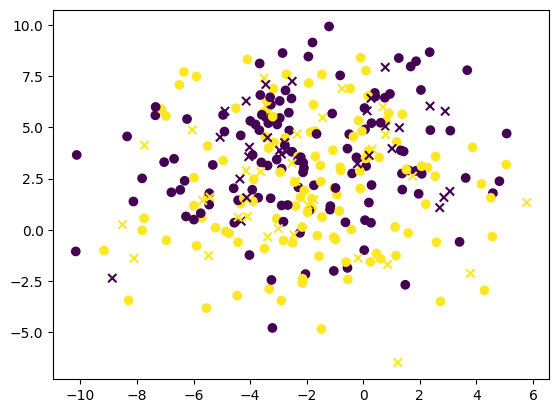

In [34]:
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=2, cluster_std=3)

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2)

plt.scatter(X_treino[:,0], X_treino[:,1], c=y_treino, cmap='viridis')
plt.scatter(X_teste[:,0], X_teste[:,1], c=y_teste, cmap='viridis', marker='x')
plt.show()

In [ ]:
# Solução:~>

---
## **Exercício 3**: Utilize a base de dados do **Titanic**, disponível na biblioteca `seaborn` (`sns.load_dataset('titanic')`), e realize a imputação dos valores faltantes das colunas **numéricas** utilizando o método de **K-Nearest Neighbors (KNN)**.

Para isso, implemente uma rotina que:

* Identifique, para cada instância com valor ausente, os **K vizinhos mais próximos** considerando as demais variáveis numéricas disponíveis.
* Preencha o valor ausente com a **média dos valores dos vizinhos** encontrados.

Considere que, para o cálculo das distâncias, é necessário que todas as variáveis estejam na mesma escala. Portanto, realize a **normalização ou padronização** dos dados antes de aplicar o KNN.

A imputação deve ser aplicada exclusivamente às variáveis numéricas que possuem valores ausentes na base.


In [35]:
# Solução:~>

import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## **Exercício 4**: Implemente um algoritmo de **$k$-Nearest Neighbors ($k$-NN)** para realizar a predição dos valores de fechamento de criptomoedas utilizando séries temporais janeladas.

### Descrição da Tarefa:

* Utilize os dados de **fechamento diário do Bitcoin (BTC)** e do **Ethereum (ETH)** referentes aos anos de **2023 e 2024**.
* Construa um conjunto de dados no formato de **janelas deslizantes de 3 dias**, onde cada instância utiliza os valores de fechamento dos três dias anteriores para prever o fechamento do dia seguinte.

### Especificações:

* As variáveis de entrada devem ser os valores de fechamento de BTC **e** ETH nos três dias anteriores.
* A variável de saída deve ser o valor de fechamento do BTC ou do ETH no dia seguinte (escolha um dos dois para a predição).

### Regras do Algoritmo:

* Implemente um modelo baseado em KNN, utilizando como critério de similaridade a **distância Euclidiana** entre os vetores formados pelas janelas temporais.
* Utilize os dados de 2023 e 2024 para treinar o modelo e realize a predição dos valores de fechamento para o ano de **2025**.
* Considere diferentes valores de $k$ (por exemplo: $k = 1$, $3$, $5$, $7$, $11$) e avalie como isso impacta o comportamento do modelo.

### Observação: Certifique-se de que todos os dados estejam devidamente alinhados e ordenados no tempo.


In [36]:
import yfinance as yf


btc = yf.download("BTC-USD", start="2023-01-01", end="2024-12-31", progress=False)
prices_btc_treino = btc['Close'].values
eth = yf.download("ETH-USD", start="2023-01-01", end="2024-12-31", progress=False)
prices_eth_treino = eth['Close'].values


btc = yf.download("BTC-USD", start="2025-01-01", end="2025-06-01", progress=False)
prices_btc_teste = btc['Close'].values
eth = yf.download("ETH-USD", start="2025-01-01", end="2025-06-01", progress=False)
prices_eth_teste = eth['Close'].values


/tmp/ipykernel_5814/4207499041.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2023-01-01", end="2024-12-31", progress=False)
/tmp/ipykernel_5814/4207499041.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth = yf.download("ETH-USD", start="2023-01-01", end="2024-12-31", progress=False)
/tmp/ipykernel_5814/4207499041.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2025-01-01", end="2025-06-01", progress=False)
/tmp/ipykernel_5814/4207499041.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  eth = yf.download("ETH-USD", start="2025-01-01", end="2025-06-01", progress=False)


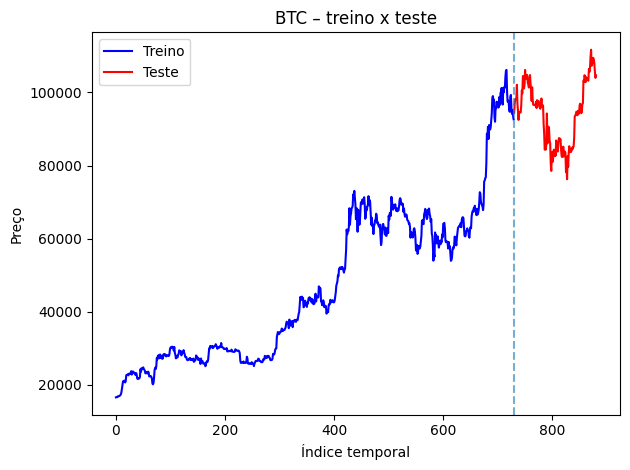

In [38]:
plt.plot(np.arange(len(prices_btc_treino)),prices_btc_treino,'b', label='Treino')
plt.plot([l+len(prices_btc_treino) for l in np.arange(len(prices_btc_teste))],prices_btc_teste,'r', label='Teste')

# linha vertical marcando a divisão
plt.axvline(len(prices_btc_treino)-1, linestyle='--', alpha=0.6)

plt.xlabel('Índice temporal')
plt.ylabel('Preço')
plt.title('BTC – treino x teste')
plt.legend()              # cria a legenda com “Treino” (azul) e “Teste” (vermelho)
plt.tight_layout()

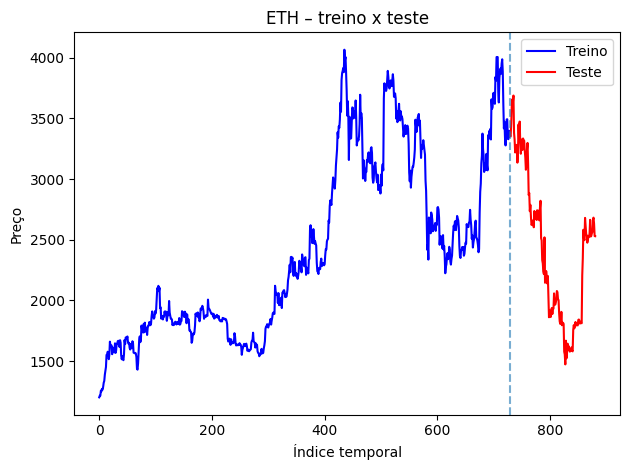

In [39]:
plt.plot(np.arange(len(prices_eth_treino)),prices_eth_treino,'b', label='Treino')
plt.plot([l+len(prices_eth_treino) for l in np.arange(len(prices_eth_teste))],prices_eth_teste,'r', label='Teste')

# linha vertical marcando a divisão
plt.axvline(len(prices_eth_treino)-1, linestyle='--', alpha=0.6)

plt.xlabel('Índice temporal')
plt.ylabel('Preço')
plt.title('ETH – treino x teste')
plt.legend()              # cria a legenda com “Treino” (azul) e “Teste” (vermelho)
plt.tight_layout()

In [46]:
# SOLUÇÃO MEU CÓDIGO, CRÉDITOS GOOGLE GEMINI
import yfinance as yf
import pandas as pd
import numpy as np

# 1. Download dos dados
# Use auto_adjust=True para evitar o aviso de FutureWarning
btc_data = yf.download("BTC-USD", start="2023-01-01", end="2025-12-31", progress=False, auto_adjust=True)
eth_data = yf.download("ETH-USD", start="2023-01-01", end="2025-12-31", progress=False, auto_adjust=True)

# 2. Correção do erro: Criando o DataFrame garantindo colunas simples
# Usamos .squeeze() para converter o DataFrame de uma coluna do yfinance em uma Series simples
df_ativos = pd.DataFrame()
df_ativos['BTC'] = btc_data['Close'].squeeze()
df_ativos['ETH'] = eth_data['Close'].squeeze()

# Remove qualquer linha com valor nulo que possa ter vindo do download
df_ativos = df_ativos.dropna()

print("Dados carregados com sucesso! Primeiras linhas:")
print(df_ativos.head())

# Agora você pode seguir com a função criar_janelas...

Dados carregados com sucesso! Primeiras linhas:
                     BTC          ETH
Date                                 
2023-01-01  16625.080078  1200.964844
2023-01-02  16688.470703  1214.656616
2023-01-03  16679.857422  1214.778809
2023-01-04  16863.238281  1256.526611
2023-01-05  16836.736328  1250.438599
